# Bonus 04 - Decision policy from set size: when the model asks for help

> "A shortlist is not a decision until operations says what to do with it." - Cairn Health nursing lead

Notebook 04 built conformal shortlists for classification. This bonus notebook turns those
sets into an operating policy. The central idea is simple: set size is not an embarrassment
and an empty set is not a bug to hide. Both are signals. The product should route them.

What you will learn:

- How to report singleton, multi-label, and empty-set behavior alongside coverage.
- How to translate prediction-set size into a safe workflow.
- Why forcing top-1 on ambiguous cases destroys the very honesty conformal prediction
  added.
- How APS changes the policy conversation by reducing empty sets at the cost of larger
  shortlists.


In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260707
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED"
)
alpha = 0.10
TEAM_NAMES = np.array(["respiratory", "cardiac", "gastro", "musculoskeletal"])
TEAM_COLORS = np.array([BLUE, RED, AMBER, PURPLE])


## 1. The clinical routing problem

Cairn Health does not need a model to sound certain. It needs the right patients routed to
the right workflow. A one-team set can be auto-routed. A two-team set should get a quick
nurse check. A three- or four-team set is a genuinely ambiguous case. An empty set is the
model saying, "none of my labels cleared the calibrated bar" - the safest response is
manual review, not top-1 bravado.


In [2]:
def simulate_cairn_triage(n, seed):
    """Synthetic telehealth intake records.

    Four care teams overlap on purpose. The symptoms are two visible composite scores plus
    two hidden intake fields. Cardiac is rarer and overlaps respiratory, which lets the
    policy table expose why averages are not enough.
    """
    rng = np.random.default_rng(seed)
    y = rng.choice(4, size=n, p=[0.38, 0.14, 0.24, 0.24])
    centers = np.array([
        [-1.4, 0.8],   # respiratory
        [-0.7, 1.15],  # cardiac, close to respiratory
        [1.25, 0.55],  # gastro
        [0.45, -1.25], # musculoskeletal
    ])
    spread = np.array([0.70, 0.78, 0.65, 0.72])
    x2 = centers[y] + rng.normal(0, spread[y, None], size=(n, 2))
    severity = 0.45 * x2[:, 1] + rng.normal(0, 0.8, size=n) + 0.35 * (y == 1)
    duration = rng.gamma(2.2 + 0.25 * y, 1.0, size=n) + 0.25 * rng.normal(size=n)
    X = np.column_stack([x2, severity, duration])
    return X, y

X_all, y_all = simulate_cairn_triage(6500, seed=RANDOM_SEED)
X_train, X_rest, y_train, y_rest = train_test_split(
    X_all, y_all, train_size=2800, random_state=RANDOM_SEED, stratify=y_all
)
X_cal, X_test, y_cal, y_test = train_test_split(
    X_rest, y_rest, train_size=1800, random_state=RANDOM_SEED, stratify=y_rest
)

clf = GradientBoostingClassifier(random_state=RANDOM_SEED)
clf.fit(X_train, y_train)
proba_cal = clf.predict_proba(X_cal)
proba_test = clf.predict_proba(X_test)
classes = clf.classes_
print(f"train/cal/test: {len(y_train):,} / {len(y_cal):,} / {len(y_test):,}")
print("test class counts:", dict(zip(TEAM_NAMES, np.bincount(y_test, minlength=4))))


train/cal/test: 2,800 / 1,800 / 1,900
test class counts: {np.str_('respiratory'): np.int64(707), np.str_('cardiac'): np.int64(270), np.str_('gastro'): np.int64(469), np.str_('musculoskeletal'): np.int64(454)}


## 2. LAC sets: the honest shortlist, including blanks

The LAC score is one minus the model probability assigned to the true label. Calibration
sets a probability bar. At test time, every label above the bar joins the shortlist. If no
label clears the bar, the set is empty. That is a product state, not an exception.


In [3]:
n_cal = len(y_cal)
q_level = math.ceil((n_cal + 1) * (1 - alpha)) / n_cal
assert q_level <= 1.0, "too few calibration patients for this alpha"
cal_scores = 1.0 - proba_cal[np.arange(n_cal), y_cal]
q_lac = np.quantile(cal_scores, q_level, method="higher")
prob_bar = 1.0 - q_lac
sets_lac = proba_test >= prob_bar
covered_lac = sets_lac[np.arange(len(y_test)), y_test]
sizes_lac = sets_lac.sum(axis=1)

print(f"calibrated probability bar: {prob_bar:.3f}")
print(f"coverage: {covered_lac.mean():.3f} against target {1 - alpha:.2f}")
print("set-size counts:", dict(zip(*np.unique(sizes_lac, return_counts=True))))


calibrated probability bar: 0.194
coverage: 0.898 against target 0.90
set-size counts: {np.int64(1): np.int64(1412), np.int64(2): np.int64(470), np.int64(3): np.int64(18)}


## 3. A policy table, not just a metric table

Now the statistics become operations. The table below is deliberately plain. It should be
owned by the product and clinical teams, not hidden in a model card appendix.


In [4]:
def action_for_size(size):
    if size == 0:
        return "manual review - no label cleared bar"
    if size == 1:
        return "auto-route"
    if size == 2:
        return "nurse quick check"
    return "senior review"

policy = pd.DataFrame({
    "set_size": [0, 1, 2, "3 or 4"],
    "routing_action": [
        "manual review - no label cleared bar",
        "auto-route to named team",
        "nurse quick check between two teams",
        "senior review for ambiguous intake",
    ],
    "why": [
        "the calibrated bar rejected every label; forcing top-1 would fake certainty",
        "the model and calibration threshold agree on one clear route",
        "the patient is plausible for two teams; speed matters but so does safety",
        "large set size is the triage signal itself",
    ],
})
policy


,set_size,routing_action,why
0,0,manual review - no label cleared bar,the calibrated bar rejected every label; forci...
1,1,auto-route to named team,the model and calibration threshold agree on o...
2,2,nurse quick check between two teams,the patient is plausible for two teams; speed ...
3,3 or 4,senior review for ambiguous intake,large set size is the triage signal itself


In [5]:
actions_lac = np.array([action_for_size(s) for s in sizes_lac])
summary_lac = pd.DataFrame({
    "metric": [
        "coverage",
        "average set size",
        "singleton / auto-route rate",
        "empty-set / manual-review rate",
        "multi-team review rate",
    ],
    "value": [
        covered_lac.mean(),
        sizes_lac.mean(),
        np.mean(sizes_lac == 1),
        np.mean(sizes_lac == 0),
        np.mean(sizes_lac >= 2),
    ],
})
summary_lac.round(3)


,metric,value
0,coverage,0.898
1,average set size,1.266
2,singleton / auto-route rate,0.743
3,empty-set / manual-review rate,0.000
4,multi-team review rate,0.257


The empty-set rate belongs in the launch review. Suppressing it by returning the top class
would make the dashboard cleaner and the workflow less honest.


In [6]:
top1 = proba_test.argmax(axis=1)
top1_name = TEAM_NAMES[top1]
set_labels = [list(TEAM_NAMES[row]) for row in sets_lac]
case_table = pd.DataFrame({
    "symptom_score_1": X_test[:, 0],
    "symptom_score_2": X_test[:, 1],
    "top_guess": top1_name,
    "top_probability": proba_test.max(axis=1),
    "conformal_shortlist": set_labels,
    "set_size": sizes_lac,
    "routing_action": actions_lac,
    "true_team": TEAM_NAMES[y_test],
})
interesting = np.r_[
    np.flatnonzero(sizes_lac == 0)[:3],
    np.flatnonzero(sizes_lac == 1)[:3],
    np.flatnonzero(sizes_lac == 2)[:3],
    np.flatnonzero(sizes_lac >= 3)[:3],
]
case_table.iloc[interesting].round(3)


,symptom_score_1,symptom_score_2,top_guess,top_probability,conformal_shortlist,set_size,routing_action,true_team
0,-2.022,0.752,respiratory,0.945,[respiratory],1,auto-route,respiratory
1,-0.278,-1.340,musculoskeletal,0.993,[musculoskeletal],1,auto-route,musculoskeletal
3,-1.265,-0.135,respiratory,0.842,[respiratory],1,auto-route,respiratory
4,-1.200,0.046,respiratory,0.783,"[respiratory, cardiac]",2,nurse quick check,respiratory
9,-0.634,1.930,respiratory,0.505,"[respiratory, cardiac]",2,nurse quick check,respiratory
10,-0.849,1.003,respiratory,0.538,"[respiratory, cardiac]",2,nurse quick check,respiratory
2,-0.501,-0.188,cardiac,0.465,"[respiratory, cardiac, musculoskeletal]",3,senior review,respiratory
325,-0.087,0.701,respiratory,0.523,"[respiratory, cardiac, gastro]",3,senior review,gastro
373,-0.648,-0.470,musculoskeletal,0.416,"[respiratory, cardiac, musculoskeletal]",3,senior review,respiratory


## 4. APS changes the routing conversation

Adaptive prediction sets (APS) include labels in probability order until the cumulative
probability clears the calibrated threshold. The practical effect is usually fewer empty
sets and more small multi-label sets. That is not automatically better. It is a different
operating policy.


In [7]:
order_cal = np.argsort(-proba_cal, axis=1)
cum_cal = np.take_along_axis(proba_cal, order_cal, axis=1).cumsum(axis=1)
rank_true = (order_cal == y_cal[:, None]).argmax(axis=1)
aps_scores = cum_cal[np.arange(n_cal), rank_true]
q_aps = np.quantile(aps_scores, q_level, method="higher")

order_test = np.argsort(-proba_test, axis=1)
cum_test = np.take_along_axis(proba_test, order_test, axis=1).cumsum(axis=1)
keep_sorted = cum_test <= q_aps
keep_sorted[:, 0] = True  # top label always stays; avoids blank shortlists
sets_aps = np.zeros_like(keep_sorted, dtype=bool)
for i in range(len(y_test)):
    sets_aps[i, order_test[i]] = keep_sorted[i]

covered_aps = sets_aps[np.arange(len(y_test)), y_test]
sizes_aps = sets_aps.sum(axis=1)

compare = pd.DataFrame({
    "method": ["LAC", "APS"],
    "coverage": [covered_lac.mean(), covered_aps.mean()],
    "avg_set_size": [sizes_lac.mean(), sizes_aps.mean()],
    "empty_rate": [np.mean(sizes_lac == 0), np.mean(sizes_aps == 0)],
    "singleton_rate": [np.mean(sizes_lac == 1), np.mean(sizes_aps == 1)],
    "review_rate_size_ge_2": [np.mean(sizes_lac >= 2), np.mean(sizes_aps >= 2)],
})
compare.round(3)


,method,coverage,avg_set_size,empty_rate,singleton_rate,review_rate_size_ge_2
0,LAC,0.898,1.266,0.0,0.743,0.257
1,APS,0.937,1.846,0.0,0.374,0.626


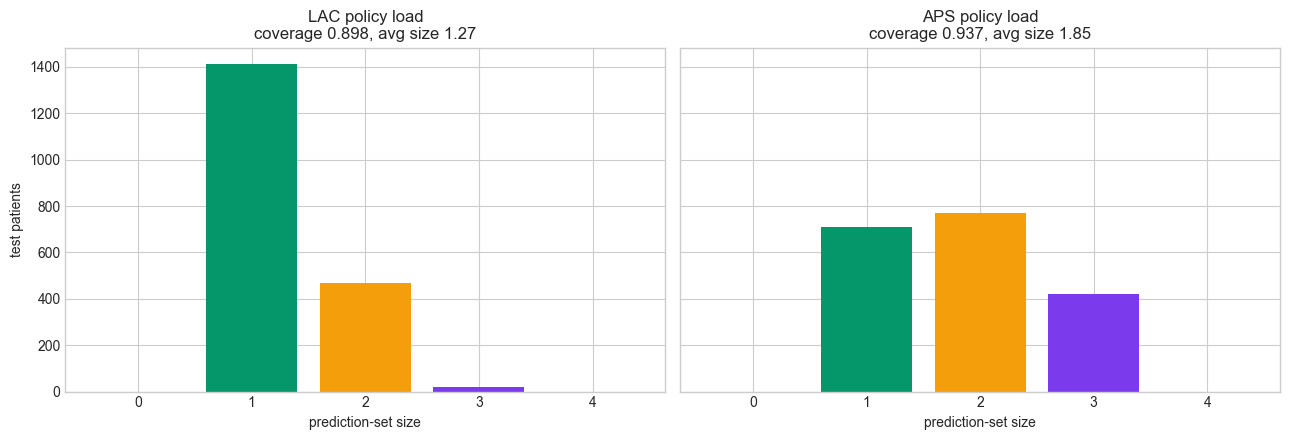

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, title, sizes, covered in [
    (axes[0], "LAC policy load", sizes_lac, covered_lac),
    (axes[1], "APS policy load", sizes_aps, covered_aps),
]:
    counts = pd.Series(sizes).value_counts().reindex([0, 1, 2, 3, 4], fill_value=0)
    ax.bar(counts.index, counts.values, color=[RED, GREEN, AMBER, PURPLE, PURPLE])
    ax.set_title(f"{title}\ncoverage {covered.mean():.3f}, avg size {sizes.mean():.2f}")
    ax.set_xlabel("prediction-set size")
    ax.set_xticks([0, 1, 2, 3, 4])
axes[0].set_ylabel("test patients")
plt.tight_layout()


## 5. What to say in the operations review

**Strong version:**

> The classifier returns calibrated shortlists, not forced answers. Singletons auto-route.
> Two-team sets get a nurse quick check. Larger sets and empty sets go to manual review.
> We report coverage, average set size, empty-set rate, and review load. APS removes blank
> sets but increases the share of multi-team reviews, so the choice is an operations trade.

**Weak version:**

> The classifier is 90% reliable.

The weak version hides the workflow. The strong version names exactly what happens when the
model is unsure.


### The one-line summary

Prediction-set size is not a cosmetic metric; it is the bridge from conformal validity to a
safe human workflow.
